# MÓDULO 4
## Tema 4. Pandas

Este cuaderno recopila lo imprescindible para empezar con **pandas** desde cero, con ejemplos realistas y progresivos.

Objetivos:
- Entender qué es un **DataFrame** y una **Series**
- Cargar datos y hacer una primera exploración (`head`, `info`, `describe`)
- Seleccionar, filtrar, ordenar y transformar datos (`loc`, `iloc`, máscaras)
- Combinar tablas (concatenar y hacer *joins* con `merge`)
- Exportar resultados

> Nota: pandas trabaja mejor cuando los datos están “limpios”. Aun así, veremos valores nulos, tipos y casos habituales de limpieza.


## Índice

- Introducción a pandas y estructuras (DataFrame / Series)
- Operaciones básicas y combinaciones (incluye `concat`)
- Carga de datos y exploración
- Tratamiento de valores nulos
- Selección y filtrado (columnas/filas, `loc`, `iloc`)
- Transformaciones, agrupaciones (`groupby`) y ordenación
- Exportación


# Introducción a pandas

__pandas es una librería de análisis de datos en Python__ que nos provee de las estructuras de datos y herramientas para realizar análisis de manera rápida. Se articula sobre la biblioteca NumPy y nos permite enfrentarnos a situaciones en las que tenemos que manejar datos reales que requieren seguir un proceso de carga, limpieza, filtrado, reduccióń y análisis. 

_En esta clase veremos como cargar y guardar datos, las características de las pricipales estructuras de pandas y las aplicaremos a algunos problemas._

### Instalación de librerías

In [ ]:
!pip install pandas openpyxl

In [4]:
!pip list

Package                  Version
------------------------ -----------
annotated-types          0.7.0
anyio                    4.12.0
asgiref                  3.11.0
asttokens                3.0.1
babel                    2.17.0
cachetools               6.2.4
certifi                  2025.11.12
charset-normalizer       3.4.4
colorama                 0.4.6
comm                     0.2.3
contourpy                1.3.3
customtkinter            5.2.2
cycler                   0.12.1
darkdetect               0.8.0
debugpy                  1.8.19
decorator                5.2.1
distro                   1.9.0
Django                   6.0.1
et_xmlfile               2.0.0
executing                2.2.1
fonttools                4.61.1
google-api-core          2.28.1
google-api-python-client 2.187.0
google-auth              2.41.1
google-auth-httplib2     0.3.0
google-auth-oauthlib     1.2.3
googleapis-common-protos 1.72.0
greenlet                 3.3.0
gspread                  6.2.1
h11            

In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

## Conozcamos pandas

Pandas tiene 3 estructuras de datos principales: DataFrame, Series y Panels (más avanzada).
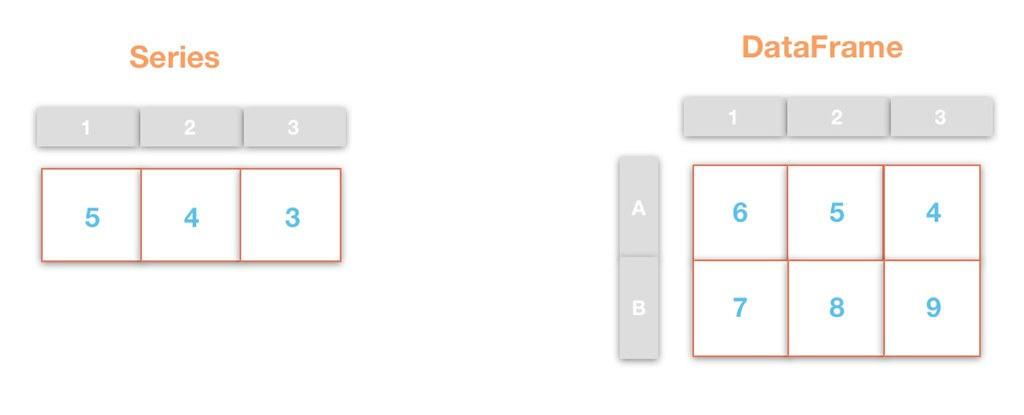

### Dataframe
El DataFrame es una estructura de datos tabular que se compone de columnas y filas ordenadas. Para que todo sea más sencillo vamos a ver un ejemplo de creación de un DataFrame (tabla) de un diccionario de listas. El siguiente ejemplo muestra un diccionario que consta de dos keys, Name y Age, y su correspondiente lista de valores.

In [ ]:
name_age = {"Name" : ["Ali", "Bill", "David", "Hany", "Ibtisam"],
            "Age" : [32, 55, 20, 43, 30]
           }
df = pd.DataFrame(name_age)
df
# Jupyter nos genera una visualización más bonita de las tablas 
# si ponemos la variable directamente en vez de print(data_frame)

In [ ]:
print(type(df))

In [ ]:
# Cambiar el orden de las columnas
df2 = pd.DataFrame(name_age, columns = ['Age', 'Name'])
df2

In [ ]:
# Se pueden generar alias para los nombres de nuestras filas
df2 = pd.DataFrame(name_age, columns = ['Name', 'Age'], index = ['a', 'b', 'c', 'd', 'e'])
df2

### Series
Series es un objeto unidimensional (1D) similar a la columna de una tabla. Si queremos crear un Series para un listado de nombres, podemos hacer lo siguiente:

In [ ]:
nombres = ['Ali', 'Bill', 'David', 'Hany', 'Ibtisam']
series = pd.Series(nombres, index=[1,2,3,4,5], name="Nombres")
print(series)

In [ ]:
print(type(series))

#### Funciones de combinación, unión o separación

- __add__: Se utiliza para sumar dos DataFrames o Series, elemento por elemento. Si tienes dos conjuntos de datos con los mismos índices y columnas, add sumará cada elemento de un conjunto de datos con el elemento correspondiente del otro.
- __concat__: Se usa para unir dos o más DataFrames o Series. Imagina que tienes dos listas de datos y quieres poner una después de la otra o una al lado de la otra; eso es lo que hace concat. Puedes unirlos verticalmente (uno encima del otro) o horizontalmente (uno al lado del otro).

In [ ]:
# Creando dos DataFrames de ejemplo
df1 = pd.DataFrame({'A': [1, 2, 3], 'B': [4, 5, 6]})
df2 = pd.DataFrame({'A': [10, 20, 30], 'B': [40, 50, 60]})

df_sumado = df1.add(df2)
print(df_sumado)

In [ ]:
# Concatenando los DataFrames de manera horizontal
df_concatenado_horizontal = pd.concat([df1, df2], axis=1)
print(df_concatenado_horizontal)

In [ ]:
# Concatenando los DataFrames de manera vertical
df_concatenado_vertical = pd.concat([df1, df2], axis=0)
print(df_concatenado_vertical)

In [ ]:
# Obtener una muestra aleatoria del 50% del DataFrame original
df_muestra = df_concatenado_vertical.sample(frac=0.5)
df_muestra

# Si quieres que la muestra sea reproducible, puedes fijar una semilla para el generador de números aleatorios
# df_muestra = df_concatenado.sample(frac=0.5, random_state=1)

# Si quieres que la muestra sea fija y no aleatoria (loc se verá más adelante)
# df_muestra = df.loc[0:int(len(df) * 0.5)] # Obtener un subconjunto fijo del 50% de las filas

## Combinar tablas: `concat` vs `merge` (JOIN)

Hasta aquí hemos visto `concat` (pegar DataFrames “uno encima de otro” o “lado a lado”).
Cuando lo que quieres es **relacionar** tablas por una clave (como en bases de datos), lo habitual es usar `merge`.

**Cuándo usar cada uno**
- `pd.concat([...])`: apilar o unir por índice (no “cruza” filas por una clave).
- `df.merge(...)`: unir por columnas clave (equivalente a JOIN SQL).

**Tipos de JOIN (parámetro `how`)**
- `inner`: solo filas con clave en ambos
- `left`: todas las filas de la izquierda, y lo que coincida de la derecha
- `right`: al revés
- `outer`: todas las filas de ambos (rellena con NaN donde no haya coincidencia)


In [ ]:
import pandas as pd

# Tabla de clientes (dimensión)
clientes = pd.DataFrame({
    "email": ["ana@example.com", "luis@example.com", "eva@example.com"],
    "nombre": ["Ana", "Luis", "Eva"],
    "pais": ["ES", "ES", "PT"],
})

# Tabla de pedidos (hechos)
pedidos = pd.DataFrame({
    "order_id": [101, 102, 103, 104],
    "email": ["ana@example.com", "ana@example.com", "luis@example.com", "desconocido@example.com"],
    "total": [19.99, 3.50, 55.00, 9.99],
    "status": ["paid", "paid", "pending", "paid"],
})

# INNER JOIN: solo pedidos con cliente conocido
inner = pedidos.merge(clientes, on="email", how="inner")
print("INNER JOIN (solo emails que están en ambas tablas):")
display(inner)

# LEFT JOIN: conserva TODOS los pedidos, aunque no exista el cliente (quedará NaN)
left = pedidos.merge(clientes, on="email", how="left", indicator=True)
print("\nLEFT JOIN (todos los pedidos, marcando coincidencia):")
display(left)

# Truco útil: ver qué filas no encontraron match
no_match = left[left["_merge"] != "both"]
print("\nFilas sin match (pedido sin cliente):")
display(no_match)


## Ejemplo de carga de datos y exploración
Trabajaremos con el fichero csv weather.csv

#### Carga del csv

In [2]:
df = pd.read_csv('weather.csv', delimiter=',')
df


,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary
0,2006-04-01 00:00:00.000 +0200,Partly Cloudy,rain,9.472222,7.388889,0.89,14.1197,251.0,15.8263,0.0,1015.13,Partly cloudy throughout the day.
1,2006-04-01 01:00:00.000 +0200,Partly Cloudy,rain,9.355556,7.227778,0.86,14.2646,259.0,15.8263,0.0,1015.63,Partly cloudy throughout the day.
2,2006-04-01 02:00:00.000 +0200,Mostly Cloudy,rain,9.377778,9.377778,0.89,3.9284,204.0,14.9569,0.0,1015.94,Partly cloudy throughout the day.
3,2006-04-01 03:00:00.000 +0200,Partly Cloudy,rain,8.288889,5.944444,0.83,14.1036,269.0,15.8263,0.0,1016.41,Partly cloudy throughout the day.
4,2006-04-01 04:00:00.000 +0200,Mostly Cloudy,rain,8.755556,6.977778,0.83,11.0446,259.0,15.8263,0.0,1016.51,Partly cloudy throughout the day.
...,...,...,...,...,...,...,...,...,...,...,...,...
96448,2016-09-09 19:00:00.000 +0200,Partly Cloudy,rain,26.016667,26.016667,0.43,10.9963,31.0,16.1000,0.0,1014.36,Partly cloudy starting in the morning.
96449,2016-09-09 20:00:00.000 +0200,Partly Cloudy,rain,24.583333,24.583333,0.48,10.0947,20.0,15.5526,0.0,1015.16,Partly cloudy starting in the morning.
96450,2016-09-09 21:00:00.000 +0200,Partly Cloudy,rain,22.038889,22.038889,0.56,8.9838,30.0,16.1000,0.0,1015.66,Partly cloudy starting in the morning.
96451,2016-09-09 22:00:00.000 +0200,Partly Cloudy,rain,21.522222,21.522222,0.60,10.5294,20.0,16.1000,0.0,1015.95,Partly cloudy starting in the morning.


In [13]:
display(df)

,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary
0,2006-04-01 00:00:00.000 +0200,Partly Cloudy,rain,9.472222,7.388889,0.89,14.1197,251.0,15.8263,0.0,1015.13,Partly cloudy throughout the day.
1,2006-04-01 01:00:00.000 +0200,Partly Cloudy,rain,9.355556,7.227778,0.86,14.2646,259.0,15.8263,0.0,1015.63,Partly cloudy throughout the day.
2,2006-04-01 02:00:00.000 +0200,Mostly Cloudy,rain,9.377778,9.377778,0.89,3.9284,204.0,14.9569,0.0,1015.94,Partly cloudy throughout the day.
3,2006-04-01 03:00:00.000 +0200,Partly Cloudy,rain,8.288889,5.944444,0.83,14.1036,269.0,15.8263,0.0,1016.41,Partly cloudy throughout the day.
4,2006-04-01 04:00:00.000 +0200,Mostly Cloudy,rain,8.755556,6.977778,0.83,11.0446,259.0,15.8263,0.0,1016.51,Partly cloudy throughout the day.
...,...,...,...,...,...,...,...,...,...,...,...,...
96448,2016-09-09 19:00:00.000 +0200,Partly Cloudy,rain,26.016667,26.016667,0.43,10.9963,31.0,16.1000,0.0,1014.36,Partly cloudy starting in the morning.
96449,2016-09-09 20:00:00.000 +0200,Partly Cloudy,rain,24.583333,24.583333,0.48,10.0947,20.0,15.5526,0.0,1015.16,Partly cloudy starting in the morning.
96450,2016-09-09 21:00:00.000 +0200,Partly Cloudy,rain,22.038889,22.038889,0.56,8.9838,30.0,16.1000,0.0,1015.66,Partly cloudy starting in the morning.
96451,2016-09-09 22:00:00.000 +0200,Partly Cloudy,rain,21.522222,21.522222,0.60,10.5294,20.0,16.1000,0.0,1015.95,Partly cloudy starting in the morning.


#### Tamaño

In [ ]:
print(len(df)) # Número de filas

#### Columnas

In [ ]:
print(df.index)
print(df.columns)

#### Valores

In [ ]:
print(df.values)

#### Información general del dataframe

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96453 entries, 0 to 96452
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Formatted Date            96453 non-null  object 
 1   Summary                   96453 non-null  object 
 2   Precip Type               95936 non-null  object 
 3   Temperature (C)           96453 non-null  float64
 4   Apparent Temperature (C)  96453 non-null  float64
 5   Humidity                  96453 non-null  float64
 6   Wind Speed (km/h)         96453 non-null  float64
 7   Wind Bearing (degrees)    96453 non-null  float64
 8   Visibility (km)           96453 non-null  float64
 9   Loud Cover                96453 non-null  float64
 10  Pressure (millibars)      96453 non-null  float64
 11  Daily Summary             96453 non-null  object 
dtypes: float64(8), object(4)
memory usage: 8.8+ MB


In [ ]:
df.shape # Tupla de filas y columnas

In [15]:
df.describe() # Resumen estadistico de las columnas numéricas

,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars)
count,96453.000000,96453.000000,96453.000000,96453.000000,96453.000000,96453.000000,96453.0,96453.000000
mean,11.932678,10.855029,0.734899,10.810640,187.509232,10.347325,0.0,1003.235956
std,9.551546,10.696847,0.195473,6.913571,107.383428,4.192123,0.0,116.969906
min,-21.822222,-27.716667,0.000000,0.000000,0.000000,0.000000,0.0,0.000000
25%,4.688889,2.311111,0.600000,5.828200,116.000000,8.339800,0.0,1011.900000
50%,12.000000,12.000000,0.780000,9.965900,180.000000,10.046400,0.0,1016.450000
75%,18.838889,18.838889,0.890000,14.135800,290.000000,14.812000,0.0,1021.090000
max,39.905556,39.344444,1.000000,63.852600,359.000000,16.100000,0.0,1046.380000


In [16]:
df.describe(include='object')

,Formatted Date,Summary,Precip Type,Daily Summary
count,96453,96453,95936,96453
unique,96429,27,2,214
top,2010-08-02 00:00:00.000 +0200,Partly Cloudy,rain,Mostly cloudy throughout the day.
freq,2,31733,85224,20085


#### Head y Tail

In [17]:
df.head() # Primeras 5 filas

,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary
0,2006-04-01 00:00:00.000 +0200,Partly Cloudy,rain,9.472222,7.388889,0.89,14.1197,251.0,15.8263,0.0,1015.13,Partly cloudy throughout the day.
1,2006-04-01 01:00:00.000 +0200,Partly Cloudy,rain,9.355556,7.227778,0.86,14.2646,259.0,15.8263,0.0,1015.63,Partly cloudy throughout the day.
2,2006-04-01 02:00:00.000 +0200,Mostly Cloudy,rain,9.377778,9.377778,0.89,3.9284,204.0,14.9569,0.0,1015.94,Partly cloudy throughout the day.
3,2006-04-01 03:00:00.000 +0200,Partly Cloudy,rain,8.288889,5.944444,0.83,14.1036,269.0,15.8263,0.0,1016.41,Partly cloudy throughout the day.
4,2006-04-01 04:00:00.000 +0200,Mostly Cloudy,rain,8.755556,6.977778,0.83,11.0446,259.0,15.8263,0.0,1016.51,Partly cloudy throughout the day.


In [18]:
df.head(10) # Primeras 10 filas

,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary
0,2006-04-01 00:00:00.000 +0200,Partly Cloudy,rain,9.472222,7.388889,0.89,14.1197,251.0,15.8263,0.0,1015.13,Partly cloudy throughout the day.
1,2006-04-01 01:00:00.000 +0200,Partly Cloudy,rain,9.355556,7.227778,0.86,14.2646,259.0,15.8263,0.0,1015.63,Partly cloudy throughout the day.
2,2006-04-01 02:00:00.000 +0200,Mostly Cloudy,rain,9.377778,9.377778,0.89,3.9284,204.0,14.9569,0.0,1015.94,Partly cloudy throughout the day.
3,2006-04-01 03:00:00.000 +0200,Partly Cloudy,rain,8.288889,5.944444,0.83,14.1036,269.0,15.8263,0.0,1016.41,Partly cloudy throughout the day.
4,2006-04-01 04:00:00.000 +0200,Mostly Cloudy,rain,8.755556,6.977778,0.83,11.0446,259.0,15.8263,0.0,1016.51,Partly cloudy throughout the day.
5,2006-04-01 05:00:00.000 +0200,Partly Cloudy,rain,9.222222,7.111111,0.85,13.9587,258.0,14.9569,0.0,1016.66,Partly cloudy throughout the day.
6,2006-04-01 06:00:00.000 +0200,Partly Cloudy,rain,7.733333,5.522222,0.95,12.3648,259.0,9.9820,0.0,1016.72,Partly cloudy throughout the day.
7,2006-04-01 07:00:00.000 +0200,Partly Cloudy,rain,8.772222,6.527778,0.89,14.1519,260.0,9.9820,0.0,1016.84,Partly cloudy throughout the day.
8,2006-04-01 08:00:00.000 +0200,Partly Cloudy,rain,10.822222,10.822222,0.82,11.3183,259.0,9.9820,0.0,1017.37,Partly cloudy throughout the day.
9,2006-04-01 09:00:00.000 +0200,Partly Cloudy,rain,13.772222,13.772222,0.72,12.5258,279.0,9.9820,0.0,1017.22,Partly cloudy throughout the day.


In [ ]:
df.tail() # Ultimas 5 filas

In [ ]:
df.tail(10) # Ultimas 10 filas

#### Slicing

In [19]:
# Hacer slicing al dataframe, obtener 10 filas ubicadas entre las filas 20 y 30
df[20:31]

,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary
20,2006-04-01 20:00:00.000 +0200,Mostly Cloudy,rain,11.550000,11.550000,0.77,7.3899,147.0,11.0285,0.0,1015.85,Partly cloudy throughout the day.
21,2006-04-01 21:00:00.000 +0200,Mostly Cloudy,rain,11.183333,11.183333,0.76,4.9266,160.0,9.9820,0.0,1015.77,Partly cloudy throughout the day.
22,2006-04-01 22:00:00.000 +0200,Partly Cloudy,rain,10.116667,10.116667,0.79,6.6493,163.0,15.8263,0.0,1015.40,Partly cloudy throughout the day.
23,2006-04-01 23:00:00.000 +0200,Mostly Cloudy,rain,10.200000,10.200000,0.77,3.9284,152.0,14.9569,0.0,1015.51,Partly cloudy throughout the day.
24,2006-04-10 00:00:00.000 +0200,Partly Cloudy,rain,10.422222,10.422222,0.62,16.9855,150.0,15.8263,0.0,1014.40,Mostly cloudy throughout the day.
25,2006-04-10 01:00:00.000 +0200,Partly Cloudy,rain,9.911111,7.566667,0.66,17.2109,149.0,15.8263,0.0,1014.20,Mostly cloudy throughout the day.
26,2006-04-10 02:00:00.000 +0200,Mostly Cloudy,rain,11.183333,11.183333,0.80,10.8192,163.0,14.9569,0.0,1008.71,Mostly cloudy throughout the day.
27,2006-04-10 03:00:00.000 +0200,Partly Cloudy,rain,7.155556,5.044444,0.79,11.0768,180.0,15.8263,0.0,1014.47,Mostly cloudy throughout the day.
28,2006-04-10 04:00:00.000 +0200,Partly Cloudy,rain,6.111111,4.816667,0.82,6.6493,161.0,15.8263,0.0,1014.45,Mostly cloudy throughout the day.
29,2006-04-10 05:00:00.000 +0200,Partly Cloudy,rain,6.788889,4.272222,0.83,13.0088,135.0,14.9569,0.0,1014.49,Mostly cloudy throughout the day.


In [21]:
# Acceder a una única fila
df[20:21]

,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary
20,2006-04-01 20:00:00.000 +0200,Mostly Cloudy,rain,11.55,11.55,0.77,7.3899,147.0,11.0285,0.0,1015.85,Partly cloudy throughout the day.


#### Acceder a una columna en concreto

In [22]:
df['Humidity']

0        0.89
1        0.86
2        0.89
3        0.83
4        0.83
         ... 
96448    0.43
96449    0.48
96450    0.56
96451    0.60
96452    0.61
Name: Humidity, Length: 96453, dtype: float64

In [23]:
# Acceder a una columna en particular del dataframe
df['Humidity'].head(10) 

0    0.89
1    0.86
2    0.89
3    0.83
4    0.83
5    0.85
6    0.95
7    0.89
8    0.82
9    0.72
Name: Humidity, dtype: float64

In [24]:
df['Humidity'][100:110] # Acceder a un rango de filas de una columna específica

100    0.70
101    0.73
102    0.76
103    0.76
104    0.76
105    0.71
106    0.73
107    0.72
108    0.70
109    0.70
Name: Humidity, dtype: float64

In [25]:
df[100:106]["Humidity"] # Otra forma de acceder a un rango de filas de una columna específica

100    0.70
101    0.73
102    0.76
103    0.76
104    0.76
105    0.71
Name: Humidity, dtype: float64

#### Minimo, maximo y promedio de una columna

In [ ]:
print(df['Humidity'].min())
print(df['Humidity'].max())
print(df['Humidity'].mean())

0.0
1.0
0.7426999999999999


In [ ]:
print(df['Humidity'][:1000].mean())

#### Contar elementos dentro de una columna

In [6]:
df['Precip Type'].value_counts()

Precip Type
rain    85224
snow    10712
Name: count, dtype: int64

In [ ]:
# Y por cierto, si queremos extraer esta info de la serie que nos devuelve podemos hacer lo siguiente
precip_counts = df['Precip Type'].value_counts()
print(precip_counts['rain'])
print(precip_counts['snow'])

In [ ]:
# U otra alternativa
precip_counts_dict = df['Precip Type'].value_counts().to_dict()
print(precip_counts_dict)
for clave, valor in precip_counts_dict.items():
    print(clave, "->", valor)

#### Otras funciones de formato (para textos)

In [ ]:
df["Summary"].str.upper()

0        PARTLY CLOUDY
1        PARTLY CLOUDY
2        MOSTLY CLOUDY
3        PARTLY CLOUDY
4        MOSTLY CLOUDY
             ...      
96448    PARTLY CLOUDY
96449    PARTLY CLOUDY
96450    PARTLY CLOUDY
96451    PARTLY CLOUDY
96452    PARTLY CLOUDY
Name: Summary, Length: 96453, dtype: object

In [8]:
df["Summary"].str.lower()

0        partly cloudy
1        partly cloudy
2        mostly cloudy
3        partly cloudy
4        mostly cloudy
             ...      
96448    partly cloudy
96449    partly cloudy
96450    partly cloudy
96451    partly cloudy
96452    partly cloudy
Name: Summary, Length: 96453, dtype: object

In [9]:
df["Summary"].str.capitalize()

0        Partly cloudy
1        Partly cloudy
2        Mostly cloudy
3        Partly cloudy
4        Mostly cloudy
             ...      
96448    Partly cloudy
96449    Partly cloudy
96450    Partly cloudy
96451    Partly cloudy
96452    Partly cloudy
Name: Summary, Length: 96453, dtype: object

In [10]:
df["Summary"].str.title()

0        Partly Cloudy
1        Partly Cloudy
2        Mostly Cloudy
3        Partly Cloudy
4        Mostly Cloudy
             ...      
96448    Partly Cloudy
96449    Partly Cloudy
96450    Partly Cloudy
96451    Partly Cloudy
96452    Partly Cloudy
Name: Summary, Length: 96453, dtype: object

In [11]:
df["Summary"].str.swapcase()

0        pARTLY cLOUDY
1        pARTLY cLOUDY
2        mOSTLY cLOUDY
3        pARTLY cLOUDY
4        mOSTLY cLOUDY
             ...      
96448    pARTLY cLOUDY
96449    pARTLY cLOUDY
96450    pARTLY cLOUDY
96451    pARTLY cLOUDY
96452    pARTLY cLOUDY
Name: Summary, Length: 96453, dtype: object

In [12]:
df["Summary"].str.contains("Cloudy")

0        True
1        True
2        True
3        True
4        True
         ... 
96448    True
96449    True
96450    True
96451    True
96452    True
Name: Summary, Length: 96453, dtype: bool

In [13]:
df["Summary"].unique() # Obtener una lista con los valores únicos de esta columna

array(['Partly Cloudy', 'Mostly Cloudy', 'Overcast', 'Foggy',
       'Breezy and Mostly Cloudy', 'Clear', 'Breezy and Partly Cloudy',
       'Breezy and Overcast', 'Humid and Mostly Cloudy',
       'Humid and Partly Cloudy', 'Windy and Foggy', 'Windy and Overcast',
       'Breezy and Foggy', 'Windy and Partly Cloudy', 'Breezy',
       'Dry and Partly Cloudy', 'Windy and Mostly Cloudy',
       'Dangerously Windy and Partly Cloudy', 'Dry', 'Windy',
       'Humid and Overcast', 'Light Rain', 'Drizzle', 'Windy and Dry',
       'Dry and Mostly Cloudy', 'Breezy and Dry', 'Rain'], dtype=object)

In [14]:
print(len(df["Summary"].unique()))

27


## 🧼 Tratamiento de Valores Nulos con Pandas

### ➖ Cuándo eliminar
- **Fila** → Si tiene demasiados valores vacíos o no es relevante.  
- **Columna** → Si tiene más del **60% de valores nulos** o no aporta al análisis.

### 🔄 Cuándo imputar
- Cuando los nulos son **pocos** (menos del 30%).  
- Cuando la columna es **importante** y no quieres perder información.


In [19]:
df.isnull()

,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary
0,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
96448,False,False,False,False,False,False,False,False,False,False,False,False
96449,False,False,False,False,False,False,False,False,False,False,False,False
96450,False,False,False,False,False,False,False,False,False,False,False,False
96451,False,False,False,False,False,False,False,False,False,False,False,False


In [20]:
# Número de nulos/NaN por columna
df.isnull().sum()

Formatted Date                0
Summary                       0
Precip Type                 517
Temperature (C)               0
Apparent Temperature (C)      0
Humidity                      0
Wind Speed (km/h)             0
Wind Bearing (degrees)        0
Visibility (km)               0
Loud Cover                    0
Pressure (millibars)          0
Daily Summary                 0
dtype: int64

In [ ]:
# Número total de nulos
df.isnull().sum().sum()

In [21]:
# Número de nulos en una columna concreta
df['Precip Type'].isnull().sum()

np.int64(517)

In [ ]:
# Mostrar las filas que tienen nulos
condicion = df.isnull().any(axis=1)
df[condicion]

Tenemos dos opciones con los nulos o NaN:
- Eliminarlos (dropna)
- Sustituirlos (fillna)

In [22]:
# Eliminamos los NaN (lo hacemos sobre un DF nuevo)
df2 = df.dropna() 
df2.isnull().sum()

Formatted Date              0
Summary                     0
Precip Type                 0
Temperature (C)             0
Apparent Temperature (C)    0
Humidity                    0
Wind Speed (km/h)           0
Wind Bearing (degrees)      0
Visibility (km)             0
Loud Cover                  0
Pressure (millibars)        0
Daily Summary               0
dtype: int64

In [23]:
len(df2)

95936

In [24]:
# Han quedado huecos, así que tenemos que resetear los índices
df2 = df2.reset_index(drop=True)
df2

,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary
0,2006-04-01 00:00:00.000 +0200,Partly Cloudy,rain,9.472222,7.388889,0.89,14.1197,251.0,15.8263,0.0,1015.13,Partly cloudy throughout the day.
1,2006-04-01 01:00:00.000 +0200,Partly Cloudy,rain,9.355556,7.227778,0.86,14.2646,259.0,15.8263,0.0,1015.63,Partly cloudy throughout the day.
2,2006-04-01 02:00:00.000 +0200,Mostly Cloudy,rain,9.377778,9.377778,0.89,3.9284,204.0,14.9569,0.0,1015.94,Partly cloudy throughout the day.
3,2006-04-01 03:00:00.000 +0200,Partly Cloudy,rain,8.288889,5.944444,0.83,14.1036,269.0,15.8263,0.0,1016.41,Partly cloudy throughout the day.
4,2006-04-01 04:00:00.000 +0200,Mostly Cloudy,rain,8.755556,6.977778,0.83,11.0446,259.0,15.8263,0.0,1016.51,Partly cloudy throughout the day.
...,...,...,...,...,...,...,...,...,...,...,...,...
95931,2016-09-09 19:00:00.000 +0200,Partly Cloudy,rain,26.016667,26.016667,0.43,10.9963,31.0,16.1000,0.0,1014.36,Partly cloudy starting in the morning.
95932,2016-09-09 20:00:00.000 +0200,Partly Cloudy,rain,24.583333,24.583333,0.48,10.0947,20.0,15.5526,0.0,1015.16,Partly cloudy starting in the morning.
95933,2016-09-09 21:00:00.000 +0200,Partly Cloudy,rain,22.038889,22.038889,0.56,8.9838,30.0,16.1000,0.0,1015.66,Partly cloudy starting in the morning.
95934,2016-09-09 22:00:00.000 +0200,Partly Cloudy,rain,21.522222,21.522222,0.60,10.5294,20.0,16.1000,0.0,1015.95,Partly cloudy starting in the morning.


In [ ]:
# Búsqueda y sustitución de nulos / NaN: GLOBAL
# df = df.fillna(0) 

In [ ]:
# Si quisieramos sustituir los NaN de columnas concretas

# Crear un diccionario donde la clave es el nombre de la columna 
# y el valor es lo que quieres usar para reemplazar NaN
valores_para_reemplazar = {"Temperature (C)": 0.0, "Humidity": 0.0}

# Aplicar fillna con el diccionario
df = df.fillna(valores_para_reemplazar) 
df

In [3]:
# Solucionamos el problema de nulos de Precip Type
moda = df['Precip Type'].mode()[0]
df['Precip Type'] = df['Precip Type'].fillna(moda)

Alternativas de sustitución de nulos en una columna concreta:

- Sustituir por el promedio de esa columna en caso de ser de tipo numérico

**`df['Humidity'] = df['Humidity'].fillna(df['Humidity'].mean())`**
- Sustituir por la moda de esa columna en caso de ser de tipo texto

**`df['Precip Type'] = df['Precip Type'].fillna(df['Precip Type'].mode()[0])`**

- Sustituir un valor nulo con el valor anterior en la columna

**`df['Humidity'] = df['Humidity'].ffill()`**

- Sustituir un valor nulo con el valor posterior en la columna

**`df['Humidity'] = df['Humidity'].bfill()`**

- Sustituir un valor nulo con el valor posterior y anterior en la columna (para evitar problemas con nulos en primera y última posición)

**`df['Humidity'] = df['Humidity'].bfill().ffill()`**

- Utilizar técnicas de interpolación (solo números)

**`df['Humidity'] = df['Humidity'].interpolate(method='linear')`**<br>
Importante, con este método si hay nulos en el primer y último registro, no los corregirá, habría que ejecutar ffil o bfill después de la interpolación.

Los anteriores son los métodos principales, pero a continuación se detalla una lista completa:

- linear: Este es el método predeterminado. Interpola los valores faltantes asumiendo una tasa de cambio lineal constante entre los puntos de datos conocidos.

- time: Si el DataFrame tiene un índice de tiempo, este método tendrá en cuenta la longitud del intervalo de tiempo cuando esté interpolando.

- index, values: Utiliza el índice numérico actual para la interpolación, lo cual es útil cuando el índice tiene una escala implícita.

- pad, ffill: Propaga la última observación válida para rellenar los siguientes valores NaN.

- bfill, backfill: Utiliza la siguiente observación válida para rellenar los valores NaN hacia atrás.

- nearest: Rellena los NaN con el valor más cercano en el mismo DataFrame o Serie.

- zero: Similar al método lineal, pero la interpolación resultante tendrá escalones, donde los datos se mantienen constantes entre los puntos conocidos y cambian en los puntos de datos conocidos.

- slinear, quadratic, cubic: Estos son métodos que interpolan a través de un polinomio de orden bajo. Por ejemplo, 'slinear' es lineal, 'quadratic' es un polinomio cuadrático y 'cubic' es un polinomio cúbico.

- spline: Interpola a través de una variedad de tipos de spline sobre el grado especificado. Los splines son una serie de polinomios conectados y se utilizan a menudo en los datos que tienen una curva más natural en lugar de una línea recta.

- polynomial: Interpolación polinómica general sobre el grado especificado. Es más flexible que los lineales o cuadráticos, ya que puedes definir el grado del polinomio.

- piecewise_polynomial, pchip, akima: Estos son métodos más avanzados que tratan de proporcionar una interpolación más suave que se ajuste bien a los datos.

## Selección rápida: columnas, filas, `loc` e `iloc`

En pandas hay varias formas de acceder a datos:

**Columnas**
- `df["col"]` devuelve una Series
- `df[["col1", "col2"]]` devuelve un DataFrame

**Filas**
- `df.loc[...]` selecciona por **etiqueta** (índice) y/o condición
- `df.iloc[...]` selecciona por **posición** (0..n-1)

Idea clave:
- `loc` piensa en “nombres” (índices/columnas)
- `iloc` piensa en “posiciones” (como una lista)


In [ ]:
import pandas as pd

df_demo = pd.DataFrame({
    "ciudad": ["Gijón", "Oviedo", "Avilés", "Gijón"],
    "temp": [12.5, 10.2, 11.0, 13.1],
    "lluvia": [0.0, 2.3, 0.0, 1.1],
})

# Columnas
print("Una columna (Series):")
display(df_demo["temp"])

print("Varias columnas (DataFrame):")
display(df_demo[["ciudad", "temp"]])

# Filtrado con máscara booleana
mask = df_demo["ciudad"] == "Gijón"
print("Filas donde ciudad == 'Gijón':")
display(df_demo[mask])

# loc: filas/columnas por etiqueta (aquí el índice es 0..n-1, pero sigue siendo 'etiqueta')
print("loc: filas 0 a 2 (incluye 2) y columnas seleccionadas:")
display(df_demo.loc[0:2, ["ciudad", "lluvia"]])

# iloc: filas/columnas por posición (el final NO se incluye)
print("iloc: filas 0 a 2 (no incluye 2) y columnas por posición:")
display(df_demo.iloc[0:2, 0:2])


### Condicionales simples

<code><b>df["columna"]["condicion"]</b></code> <br>
Se devuelven todos los valores de esa columna que cumplan la condición
<br>Con este método podemos mostrar:
* Una sola columna
* Todo el dataframe
<br>No podemos, mostrar un número determinado de columnas, para ello usaremos loc

In [ ]:
media_humedad = df["Humidity"].mean()
print("Media de la humedad:", media_humedad)
columna = "Humidity"
condicion = df["Humidity"] <= media_humedad
df[columna][condicion]

In [ ]:
# Mostrar una columna diferente, de la que se usa para evaluar la condicion
df["Temperature (C)"][df["Humidity"] <= media_humedad]

In [ ]:
# Mostraremos todo el dataframe (todas las columnas) que cumplan una condición
# df[condicion]
df[df["Humidity"] <= media_humedad]

In [ ]:
# Mostraremos todo el dataframe (todas las columnas) que cumplan una condición
# df[condicion]
df[df["Summary"] == "Foggy"] # Si queremos evaluar si es dintinto: !=

In [ ]:
# Condición multiple con AND (&) 
# &: and (Y lógico)
# |: or (O lógico)
df[ (df["Summary"] == "Foggy") & (df["Precip Type"] == "snow") ] 

In [ ]:
# Condición multiple con OR (|)
# &: and (Y lógico)
# |: or (O lógico)
df[ (df["Summary"] == "Foggy") | (df["Precip Type"] == "snow") ] 

In [ ]:
# Aplicar un condicional y guardar el resultado en un nuevo dataframe
df2 = df[ (df["Summary"] == "Foggy") & (df["Precip Type"] == "snow") ] 
df2

In [ ]:
df2.info()

### Condicionales complejos: loc

Con el metodo anterior o mostramos el dataframe completo o sólo una columna, pero si queremos aplicar un condicional y mostrar 2, 3 o 4 columnas no podemos, así que para estos casos usaremos el __metodo loc__, cuya estructura es la siguiente: <br><br>
<code><b>df.loc[condicion, [columna1, column2, columna3]]</b></code> <br><br>
Se devuelven todos los valores de esas columnas que cumplan la condición. Con este método podemos mostrar todas las columnas que queramos.

In [26]:
# Estructura de loc
# df.loc[condicion, [columna1, column2, columna3]]
media_humedad = df["Humidity"].mean()
df.loc[ df["Humidity"] <= media_humedad, ["Humidity", "Temperature (C)"] ]

,Humidity,Temperature (C)
9,0.72,13.772222
10,0.67,16.016667
11,0.54,17.144444
12,0.55,17.800000
13,0.51,17.333333
...,...,...
96448,0.43,26.016667
96449,0.48,24.583333
96450,0.56,22.038889
96451,0.60,21.522222


In [ ]:
# Alternativa de sintaxis al bloque anterior
condicion = df["Humidity"] <= media_humedad
lista_columnas = ["Humidity", "Temperature (C)"]
df.loc[ condicion, lista_columnas ]

,Humidity,Temperature (C)
0,0.89,9.472222
1,0.86,9.355556
2,0.89,9.377778
3,0.83,8.288889
4,0.83,8.755556
...,...,...
96448,0.43,26.016667
96449,0.48,24.583333
96450,0.56,22.038889
96451,0.60,21.522222


In [30]:
# Mostrar todas las columnas (:) que cumplan la condición
df.loc[ df["Humidity"] <= media_humedad, : ]

,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary
9,2006-04-01 09:00:00.000 +0200,Partly Cloudy,rain,13.772222,13.772222,0.72,12.5258,279.0,9.9820,0.0,1017.22,Partly cloudy throughout the day.
10,2006-04-01 10:00:00.000 +0200,Partly Cloudy,rain,16.016667,16.016667,0.67,17.5651,290.0,11.2056,0.0,1017.42,Partly cloudy throughout the day.
11,2006-04-01 11:00:00.000 +0200,Partly Cloudy,rain,17.144444,17.144444,0.54,19.7869,316.0,11.4471,0.0,1017.74,Partly cloudy throughout the day.
12,2006-04-01 12:00:00.000 +0200,Partly Cloudy,rain,17.800000,17.800000,0.55,21.9443,281.0,11.2700,0.0,1017.59,Partly cloudy throughout the day.
13,2006-04-01 13:00:00.000 +0200,Partly Cloudy,rain,17.333333,17.333333,0.51,20.6885,289.0,11.2700,0.0,1017.48,Partly cloudy throughout the day.
...,...,...,...,...,...,...,...,...,...,...,...,...
96448,2016-09-09 19:00:00.000 +0200,Partly Cloudy,rain,26.016667,26.016667,0.43,10.9963,31.0,16.1000,0.0,1014.36,Partly cloudy starting in the morning.
96449,2016-09-09 20:00:00.000 +0200,Partly Cloudy,rain,24.583333,24.583333,0.48,10.0947,20.0,15.5526,0.0,1015.16,Partly cloudy starting in the morning.
96450,2016-09-09 21:00:00.000 +0200,Partly Cloudy,rain,22.038889,22.038889,0.56,8.9838,30.0,16.1000,0.0,1015.66,Partly cloudy starting in the morning.
96451,2016-09-09 22:00:00.000 +0200,Partly Cloudy,rain,21.522222,21.522222,0.60,10.5294,20.0,16.1000,0.0,1015.95,Partly cloudy starting in the morning.


In [34]:
display(df.loc[:, ["Humidity", "Temperature (C)"]])
display(df.loc[10:15, ["Humidity", "Temperature (C)"]])
display(df.loc[10, ["Humidity", "Temperature (C)"]])
display(df.loc[10])    # Equivalente a d.loc[10, :]
display(df.loc[10:12]) # Equivalente a d.loc[10:12, :]

,Humidity,Temperature (C)
0,0.89,9.472222
1,0.86,9.355556
2,0.89,9.377778
3,0.83,8.288889
4,0.83,8.755556
...,...,...
96448,0.43,26.016667
96449,0.48,24.583333
96450,0.56,22.038889
96451,0.60,21.522222


,Humidity,Temperature (C)
10,0.67,16.016667
11,0.54,17.144444
12,0.55,17.800000
13,0.51,17.333333
14,0.47,18.877778
15,0.46,18.911111


Humidity                0.67
Temperature (C)    16.016667
Name: 10, dtype: object

Formatted Date                  2006-04-01 10:00:00.000 +0200
Summary                                         Partly Cloudy
Precip Type                                              rain
Temperature (C)                                     16.016667
Apparent Temperature (C)                            16.016667
Humidity                                                 0.67
Wind Speed (km/h)                                     17.5651
Wind Bearing (degrees)                                  290.0
Visibility (km)                                       11.2056
Loud Cover                                                0.0
Pressure (millibars)                                  1017.42
Daily Summary               Partly cloudy throughout the day.
Name: 10, dtype: object

,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary
10,2006-04-01 10:00:00.000 +0200,Partly Cloudy,rain,16.016667,16.016667,0.67,17.5651,290.0,11.2056,0.0,1017.42,Partly cloudy throughout the day.
11,2006-04-01 11:00:00.000 +0200,Partly Cloudy,rain,17.144444,17.144444,0.54,19.7869,316.0,11.4471,0.0,1017.74,Partly cloudy throughout the day.
12,2006-04-01 12:00:00.000 +0200,Partly Cloudy,rain,17.800000,17.800000,0.55,21.9443,281.0,11.2700,0.0,1017.59,Partly cloudy throughout the day.


### iloc: Herramienta muy similar a loc
El método iloc se utiliza en los DataFrames para seleccionar los elementos en base a su ubicación. <br>
__A diferencia de loc, con iloc podemos seleccionar filas PERO TAMBIÉN COLUMNAS a través de su índice__
<br>
Inconveniente: No podemos aplicar condiciones relacionales (comparativas) o lógicas

In [ ]:
df.iloc[0] # Primera fila

In [ ]:
df.iloc[:, 0] # Primera columna

In [ ]:
df.iloc[:, -1] # Última columna

In [ ]:
df.iloc[0:5] # Primeras cinco filas
# Esto seria igual que con el loc

In [ ]:
df.iloc[:, 0:5] # Primeras cinco columnas

In [ ]:
df.iloc[10:15, 0:3]

In [ ]:
df.iloc[[0,2,1], :]  # Primera, tercera y segunda filas

In [ ]:
df.iloc[:, [0,2,1]]  # Primera, tercera y segunda columnas

In [ ]:
df.iloc[:, [0,2,1]]

In [ ]:
df.iloc[[1,10,100], [7,2,5]]

In [ ]:
# Unir loc e iloc para que cada uno se encargue de lo suyo
condicion = (df["Humidity"] <= media_humedad) & (df["Summary"].str.contains("cloudy", case=False))
df2 = df.loc[condicion, :]
df2 = df2.iloc[:, [1,5,9,2]]
print(df2)

#### Reordenar columnas

In [ ]:
# Proceso manual para reordenar las columnas de un DF
lista_reordenada = ['Precip Type', 'Temperature (C)', 'Apparent Temperature (C)', 'Formatted Date', 'Summary', 'Humidity', 'Wind Speed (km/h)', 'Wind Bearing (degrees)', 'Visibility (km)', 'Loud Cover', 'Pressure (millibars)', 'Daily Summary']
df2 = df[lista_reordenada]
df2

In [ ]:
# Lo mismo pero con un método
df3 = df.reindex(columns=lista_reordenada)
df3

#### Ordenación (sort_values)

In [4]:
# Ordenar una serie
temps = df['Temperature (C)']
print(type(temps)) # Como se ve, temps es una serie de panda
temps_ordenadas = temps.sort_values(ascending=False)
print(temps_ordenadas[0:10])

<class 'pandas.core.series.Series'>
12759    39.905556
12737    39.588889
12712    38.983333
12664    38.983333
12711    38.983333
12735    38.866667
53727    38.861111
12736    38.844444
12760    38.838889
53728    38.838889
Name: Temperature (C), dtype: float64


In [5]:
# Ordenar un DF completo
df_ordenado = df.sort_values(by=["Temperature (C)", "Apparent Temperature (C)"], ascending=False)
df_ordenado

,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary
12759,2007-07-22 15:00:00.000 +0200,Clear,rain,39.905556,37.538889,0.13,23.5865,250.0,9.9820,0.0,1007.55,Partly cloudy starting in the afternoon.
12737,2007-07-21 17:00:00.000 +0200,Partly Cloudy,rain,39.588889,37.600000,0.15,12.2038,283.0,10.3523,0.0,1010.24,Partly cloudy starting in the morning continui...
12664,2007-07-19 16:00:00.000 +0200,Partly Cloudy,rain,38.983333,37.461111,0.18,8.9355,175.0,9.9820,0.0,1013.34,Partly cloudy starting in the afternoon.
12712,2007-07-20 16:00:00.000 +0200,Partly Cloudy,rain,38.983333,36.800000,0.15,15.4077,133.0,9.9820,0.0,1011.93,Partly cloudy starting in the afternoon contin...
12711,2007-07-20 15:00:00.000 +0200,Partly Cloudy,rain,38.983333,36.627778,0.14,12.7190,167.0,9.9820,0.0,1012.34,Partly cloudy starting in the afternoon contin...
...,...,...,...,...,...,...,...,...,...,...,...,...
55495,2012-02-09 07:00:00.000 +0100,Foggy,snow,-20.783333,-20.783333,0.80,4.4275,181.0,1.7871,0.0,1032.33,Foggy until morning.
55490,2012-02-09 02:00:00.000 +0100,Foggy,snow,-21.111111,-21.111111,0.74,3.2200,200.0,1.9320,0.0,1034.30,Foggy until morning.
55493,2012-02-09 05:00:00.000 +0100,Foggy,snow,-21.111111,-21.111111,0.78,4.8300,180.0,2.5760,0.0,1033.30,Foggy until morning.
55494,2012-02-09 06:00:00.000 +0100,Foggy,snow,-21.111111,-21.111111,0.71,3.2200,190.0,1.9320,0.0,1032.60,Foggy until morning.


In [7]:
df_ordenado = df_ordenado.reset_index(drop=True) # Reseteando índices
df_ordenado

,index,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary
0,12759,2007-07-22 15:00:00.000 +0200,Clear,rain,39.905556,37.538889,0.13,23.5865,250.0,9.9820,0.0,1007.55,Partly cloudy starting in the afternoon.
1,12737,2007-07-21 17:00:00.000 +0200,Partly Cloudy,rain,39.588889,37.600000,0.15,12.2038,283.0,10.3523,0.0,1010.24,Partly cloudy starting in the morning continui...
2,12664,2007-07-19 16:00:00.000 +0200,Partly Cloudy,rain,38.983333,37.461111,0.18,8.9355,175.0,9.9820,0.0,1013.34,Partly cloudy starting in the afternoon.
3,12712,2007-07-20 16:00:00.000 +0200,Partly Cloudy,rain,38.983333,36.800000,0.15,15.4077,133.0,9.9820,0.0,1011.93,Partly cloudy starting in the afternoon contin...
4,12711,2007-07-20 15:00:00.000 +0200,Partly Cloudy,rain,38.983333,36.627778,0.14,12.7190,167.0,9.9820,0.0,1012.34,Partly cloudy starting in the afternoon contin...
...,...,...,...,...,...,...,...,...,...,...,...,...,...
96448,55495,2012-02-09 07:00:00.000 +0100,Foggy,snow,-20.783333,-20.783333,0.80,4.4275,181.0,1.7871,0.0,1032.33,Foggy until morning.
96449,55490,2012-02-09 02:00:00.000 +0100,Foggy,snow,-21.111111,-21.111111,0.74,3.2200,200.0,1.9320,0.0,1034.30,Foggy until morning.
96450,55493,2012-02-09 05:00:00.000 +0100,Foggy,snow,-21.111111,-21.111111,0.78,4.8300,180.0,2.5760,0.0,1033.30,Foggy until morning.
96451,55494,2012-02-09 06:00:00.000 +0100,Foggy,snow,-21.111111,-21.111111,0.71,3.2200,190.0,1.9320,0.0,1032.60,Foggy until morning.


#### Añadir/Eliminar/Modificar columnas

In [16]:
df['Precip Type'].value_counts()

Precip Type
rain    85741
snow    10712
Name: count, dtype: int64

In [17]:
df_modificado = df.copy() # Crear una copia independiente de df
df_modificado['Precip Type'] = df['Precip Type'].map({"rain":'0',"snow":"1"})

# Primeros 3 registros donde 'Precip Type' es '0'
df_modificado.loc[df_modificado['Precip Type'] == '0'].head(3)

,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary
0,2006-04-01 00:00:00.000 +0200,Partly Cloudy,0,9.472222,7.388889,0.89,14.1197,251.0,15.8263,0.0,1015.13,Partly cloudy throughout the day.
1,2006-04-01 01:00:00.000 +0200,Partly Cloudy,0,9.355556,7.227778,0.86,14.2646,259.0,15.8263,0.0,1015.63,Partly cloudy throughout the day.
2,2006-04-01 02:00:00.000 +0200,Mostly Cloudy,0,9.377778,9.377778,0.89,3.9284,204.0,14.9569,0.0,1015.94,Partly cloudy throughout the day.


In [18]:
# Primeros 3 registros donde 'Precip Type' es '1'
df_modificado.loc[df_modificado['Precip Type'] == '1'].head(3)

,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary
1562,2006-12-13 02:00:00.000 +0100,Foggy,1,-0.483333,-4.150000,1.00,11.0929,219.0,0.483,0.0,1031.56,Foggy throughout the day.
1563,2006-12-13 03:00:00.000 +0100,Foggy,1,-0.483333,-4.061111,0.96,10.7387,200.0,0.322,0.0,1031.47,Foggy throughout the day.
1564,2006-12-13 04:00:00.000 +0100,Foggy,1,-0.922222,-3.477778,1.00,7.0679,206.0,0.161,0.0,1031.23,Foggy throughout the day.


In [ ]:
# Otro ejemplo de modificación
# Redondear los valores de la columna 'Temperature (C)' a dos decimales
df_modificado['Temperature (C)'] = df_modificado['Temperature (C)'].round(2)
df_modificado

,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary
0,2006-04-01 00:00:00.000 +0200,Partly Cloudy,0,9.47,7.388889,0.89,14.1197,251.0,15.8263,0.0,1015.13,Partly cloudy throughout the day.
1,2006-04-01 01:00:00.000 +0200,Partly Cloudy,0,9.36,7.227778,0.86,14.2646,259.0,15.8263,0.0,1015.63,Partly cloudy throughout the day.
2,2006-04-01 02:00:00.000 +0200,Mostly Cloudy,0,9.38,9.377778,0.89,3.9284,204.0,14.9569,0.0,1015.94,Partly cloudy throughout the day.
3,2006-04-01 03:00:00.000 +0200,Partly Cloudy,0,8.29,5.944444,0.83,14.1036,269.0,15.8263,0.0,1016.41,Partly cloudy throughout the day.
4,2006-04-01 04:00:00.000 +0200,Mostly Cloudy,0,8.76,6.977778,0.83,11.0446,259.0,15.8263,0.0,1016.51,Partly cloudy throughout the day.
...,...,...,...,...,...,...,...,...,...,...,...,...
96448,2016-09-09 19:00:00.000 +0200,Partly Cloudy,0,26.02,26.016667,0.43,10.9963,31.0,16.1000,0.0,1014.36,Partly cloudy starting in the morning.
96449,2016-09-09 20:00:00.000 +0200,Partly Cloudy,0,24.58,24.583333,0.48,10.0947,20.0,15.5526,0.0,1015.16,Partly cloudy starting in the morning.
96450,2016-09-09 21:00:00.000 +0200,Partly Cloudy,0,22.04,22.038889,0.56,8.9838,30.0,16.1000,0.0,1015.66,Partly cloudy starting in the morning.
96451,2016-09-09 22:00:00.000 +0200,Partly Cloudy,0,21.52,21.522222,0.60,10.5294,20.0,16.1000,0.0,1015.95,Partly cloudy starting in the morning.


In [21]:
# Si en vez de modificar la columna queremos crear una nueva:
# Crear una nueva columna 'Temperature_Rounded' con los valores redondeados
df_modificado['Temperature_Rounded'] = df_modificado['Temperature (C)'].round(2)
df_modificado

,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary,Temperature_Rounded
0,2006-04-01 00:00:00.000 +0200,Partly Cloudy,0,9.47,7.388889,0.89,14.1197,251.0,15.8263,0.0,1015.13,Partly cloudy throughout the day.,9.47
1,2006-04-01 01:00:00.000 +0200,Partly Cloudy,0,9.36,7.227778,0.86,14.2646,259.0,15.8263,0.0,1015.63,Partly cloudy throughout the day.,9.36
2,2006-04-01 02:00:00.000 +0200,Mostly Cloudy,0,9.38,9.377778,0.89,3.9284,204.0,14.9569,0.0,1015.94,Partly cloudy throughout the day.,9.38
3,2006-04-01 03:00:00.000 +0200,Partly Cloudy,0,8.29,5.944444,0.83,14.1036,269.0,15.8263,0.0,1016.41,Partly cloudy throughout the day.,8.29
4,2006-04-01 04:00:00.000 +0200,Mostly Cloudy,0,8.76,6.977778,0.83,11.0446,259.0,15.8263,0.0,1016.51,Partly cloudy throughout the day.,8.76
...,...,...,...,...,...,...,...,...,...,...,...,...,...
96448,2016-09-09 19:00:00.000 +0200,Partly Cloudy,0,26.02,26.016667,0.43,10.9963,31.0,16.1000,0.0,1014.36,Partly cloudy starting in the morning.,26.02
96449,2016-09-09 20:00:00.000 +0200,Partly Cloudy,0,24.58,24.583333,0.48,10.0947,20.0,15.5526,0.0,1015.16,Partly cloudy starting in the morning.,24.58
96450,2016-09-09 21:00:00.000 +0200,Partly Cloudy,0,22.04,22.038889,0.56,8.9838,30.0,16.1000,0.0,1015.66,Partly cloudy starting in the morning.,22.04
96451,2016-09-09 22:00:00.000 +0200,Partly Cloudy,0,21.52,21.522222,0.60,10.5294,20.0,16.1000,0.0,1015.95,Partly cloudy starting in the morning.,21.52


In [22]:
# Eliminar la columna de ejemplo
df_modificado = df_modificado.drop('Temperature_Rounded', axis=1)
df_modificado

,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary
0,2006-04-01 00:00:00.000 +0200,Partly Cloudy,0,9.47,7.388889,0.89,14.1197,251.0,15.8263,0.0,1015.13,Partly cloudy throughout the day.
1,2006-04-01 01:00:00.000 +0200,Partly Cloudy,0,9.36,7.227778,0.86,14.2646,259.0,15.8263,0.0,1015.63,Partly cloudy throughout the day.
2,2006-04-01 02:00:00.000 +0200,Mostly Cloudy,0,9.38,9.377778,0.89,3.9284,204.0,14.9569,0.0,1015.94,Partly cloudy throughout the day.
3,2006-04-01 03:00:00.000 +0200,Partly Cloudy,0,8.29,5.944444,0.83,14.1036,269.0,15.8263,0.0,1016.41,Partly cloudy throughout the day.
4,2006-04-01 04:00:00.000 +0200,Mostly Cloudy,0,8.76,6.977778,0.83,11.0446,259.0,15.8263,0.0,1016.51,Partly cloudy throughout the day.
...,...,...,...,...,...,...,...,...,...,...,...,...
96448,2016-09-09 19:00:00.000 +0200,Partly Cloudy,0,26.02,26.016667,0.43,10.9963,31.0,16.1000,0.0,1014.36,Partly cloudy starting in the morning.
96449,2016-09-09 20:00:00.000 +0200,Partly Cloudy,0,24.58,24.583333,0.48,10.0947,20.0,15.5526,0.0,1015.16,Partly cloudy starting in the morning.
96450,2016-09-09 21:00:00.000 +0200,Partly Cloudy,0,22.04,22.038889,0.56,8.9838,30.0,16.1000,0.0,1015.66,Partly cloudy starting in the morning.
96451,2016-09-09 22:00:00.000 +0200,Partly Cloudy,0,21.52,21.522222,0.60,10.5294,20.0,16.1000,0.0,1015.95,Partly cloudy starting in the morning.


In [ ]:
df['Precip Type'].value_counts()

#### Agrupaciones (groupby)
En muchos casos es muy interesante realizar agrupaciones en base a un campo (sexo, pais, etc.)

In [8]:
# Vamos a agrupar por el Summary
dfg = df.groupby("Summary")
print(type(dfg))

<class 'pandas.core.groupby.generic.DataFrameGroupBy'>


In [9]:
dfg

In [10]:
# Mostrarnos el primer registro de cada grupo
dfg.first()
dfg.last()

,Formatted Date,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary
Summary,,,,,,,,,,,
Breezy,2016-08-05 10:00:00.000 +0200,rain,27.777778,28.155556,0.49,32.1839,141.0,16.1000,0.0,1012.48,Partly cloudy starting in the afternoon.
Breezy and Dry,2012-03-18 11:00:00.000 +0100,rain,21.111111,21.111111,0.26,33.8100,240.0,9.9820,0.0,1021.60,Partly cloudy starting in the afternoon.
Breezy and Foggy,2015-02-08 17:00:00.000 +0100,snow,-0.005556,-6.977778,0.85,35.3395,321.0,1.4490,0.0,1008.46,Breezy starting in the afternoon continuing un...
Breezy and Mostly Cloudy,2016-09-17 15:00:00.000 +0200,rain,27.522222,27.766667,0.48,29.4469,260.0,9.9820,0.0,1008.80,Partly cloudy throughout the day.
Breezy and Overcast,2016-09-05 10:00:00.000 +0200,rain,17.616667,17.616667,0.90,30.9764,330.0,9.8532,0.0,1012.61,Mostly cloudy throughout the day.
Breezy and Partly Cloudy,2016-05-13 14:00:00.000 +0200,rain,21.911111,21.911111,0.46,29.5596,225.0,10.5777,0.0,997.91,Partly cloudy throughout the day and breezy in...
Clear,2016-09-09 07:00:00.000 +0200,rain,16.072222,16.072222,0.88,2.7853,12.0,15.7297,0.0,1015.25,Partly cloudy starting in the morning.
Dangerously Windy and Partly Cloudy,2007-01-29 13:00:00.000 +0100,rain,8.944444,3.483333,0.49,63.8526,307.0,11.4471,0.0,1009.05,Mostly cloudy throughout the day and windy sta...
Drizzle,2016-10-26 14:00:00.000 +0200,rain,15.194444,15.194444,0.80,18.7243,8.0,0.0000,0.0,1022.49,Rain until afternoon.


In [11]:
print("Número de grupos: ", len(dfg))

Número de grupos:  27


In [12]:
# Veamos las categorias y sus coincidencias
print(dfg.size())

Summary
Breezy                                    54
Breezy and Dry                             1
Breezy and Foggy                          35
Breezy and Mostly Cloudy                 516
Breezy and Overcast                      528
Breezy and Partly Cloudy                 386
Clear                                  10890
Dangerously Windy and Partly Cloudy        1
Drizzle                                   39
Dry                                       34
Dry and Mostly Cloudy                     14
Dry and Partly Cloudy                     86
Foggy                                   7148
Humid and Mostly Cloudy                   40
Humid and Overcast                         7
Humid and Partly Cloudy                   17
Light Rain                                63
Mostly Cloudy                          28094
Overcast                               16597
Partly Cloudy                          31733
Rain                                      10
Windy                                      8
Wi

In [ ]:
# Preguntemos por una categoria
dfg.get_group("Light Rain")

,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary
52689,2012-04-12 09:00:00.000 +0200,Light Rain,rain,12.011111,12.011111,0.75,12.1716,230.0,11.109,0.0,1002.70,Light rain in the morning.
52728,2012-04-14 00:00:00.000 +0200,Light Rain,rain,12.611111,12.611111,0.62,5.2647,55.0,16.100,0.0,999.78,Light rain until morning.
52729,2012-04-14 01:00:00.000 +0200,Light Rain,rain,11.155556,11.155556,0.85,3.5420,149.0,16.100,0.0,999.72,Light rain until morning.
52731,2012-04-14 03:00:00.000 +0200,Light Rain,rain,9.627778,8.111111,0.94,10.5294,14.0,16.100,0.0,998.15,Light rain until morning.
52732,2012-04-14 04:00:00.000 +0200,Light Rain,rain,9.588889,8.050000,0.94,10.6099,31.0,16.100,0.0,997.64,Light rain until morning.
...,...,...,...,...,...,...,...,...,...,...,...,...
95422,2016-10-26 02:00:00.000 +0200,Light Rain,rain,11.683333,11.683333,0.90,10.8836,157.0,0.000,0.0,1020.30,Rain until afternoon.
95423,2016-10-26 03:00:00.000 +0200,Light Rain,rain,11.238889,11.238889,0.91,9.5795,153.0,0.000,0.0,1019.79,Rain until afternoon.
95430,2016-10-26 10:00:00.000 +0200,Light Rain,rain,12.288889,12.288889,0.92,7.4060,8.0,0.000,0.0,1020.90,Rain until afternoon.
95431,2016-10-26 11:00:00.000 +0200,Light Rain,rain,13.255556,13.255556,0.90,11.6564,9.0,0.000,0.0,1021.49,Rain until afternoon.


In [ ]:
# Preguntemos por una categoria
dfg.get_group("Light Rain")["Humidity"].mean()

In [14]:
# Metricas por agrupacion
print(dfg.mean(numeric_only=True))
print(dfg.max(numeric_only=True))
print(dfg.min(numeric_only=True))
print(dfg.sum(numeric_only=True))
print(dfg.count())
print(dfg.nunique())

                                     Temperature (C)  \
Summary                                                
Breezy                                      7.922016   
Breezy and Dry                             21.111111   
Breezy and Foggy                           -0.510317   
Breezy and Mostly Cloudy                   11.093411   
Breezy and Overcast                         7.241614   
Breezy and Partly Cloudy                   12.492761   
Clear                                      11.925109   
Dangerously Windy and Partly Cloudy         8.944444   
Drizzle                                    10.847578   
Dry                                        29.083660   
Dry and Mostly Cloudy                      26.838492   
Dry and Partly Cloudy                      26.605749   
Foggy                                       1.464035   
Humid and Mostly Cloudy                    20.886389   
Humid and Overcast                         21.515079   
Humid and Partly Cloudy                    21.56

In [15]:
# Agrupación multiple
dfg = df.groupby(["Summary", "Precip Type"])
print(dfg.size())

Summary                              Precip Type
Breezy                               rain              42
                                     snow              12
Breezy and Dry                       rain               1
Breezy and Foggy                     rain               8
                                     snow              27
Breezy and Mostly Cloudy             rain             490
                                     snow              26
Breezy and Overcast                  rain             472
                                     snow              56
Breezy and Partly Cloudy             rain             379
                                     snow               7
Clear                                rain            9498
                                     snow            1392
Dangerously Windy and Partly Cloudy  rain               1
Drizzle                              rain              39
Dry                                  rain              34
Dry and Mostly Cloudy  

In [ ]:
# Preguntar por dos categorias en concreto
df_lightrain_rain = dfg.get_group(("Light Rain", "rain"))
df_lightrain_rain

#### Método apply(): aplicar una función a una columna

In [ ]:
def resumir(summary):
    summary = summary.lower()  # Convierte el resumen a minúsculas para una comparación uniforme
    if "breezy" in summary or "windy" in summary:
        return "Windy"
    elif "dry" in summary:
        return "Dry"
    elif "cloudy" in summary or "overcast" in summary or "partly cloudy" in summary or "mostly cloudy" in summary:
        return "Cloudy"
    elif "rain" in summary or "drizzle" in summary:
        return "Rain"
    elif "foggy" in summary:
        return "Foggy"
    elif "clear" in summary:
        return "Clear"
    else:
        return "Other"
    
df["Summary"] = df["Summary"].apply(resumir)
dfg = df.groupby("Summary")
print(dfg.size())

In [ ]:
# Si queremos exportar esta visualizacion hacemos lo siguiente
df_agrupado = dfg.size()
df_agrupado = df_agrupado.to_frame() # Esto nos va a convertir el DF agrupado en un diccionario
df_agrupado = df_agrupado.rename(columns={0:"Number of matches"})
df_agrupado.to_excel("./EXPORT_groupby.xlsx", header=True, index=True)

#### Conversión
En ocasiones, se necesita convertir una serie de pandas en una lista para poder trabajar de forma nativa desde Python

In [ ]:
temps = df['Temperature (C)']
print(type(temps)) # Como se ve, temps es una serie de panda

temps_list = df['Temperature (C)'].tolist() 
print(type(temps_list))

print("\nListado de temperaturas (mostramos solo las 10 primeras para no saturar)")
for t in temps_list[:10]:
    print(round(t, 3))

# Exportación
Vamos a seleccionar un trozo de nuestro CSV y vamos a exportarlo en varios formatos

In [23]:
# 1. Eliminar nulos
# df.dropna() # Elimino todas las filas que tengan nulos
moda = df["Precip Type"].mode()
print(moda[0]) # La moda nos devuelve una serie, asi que accedemos a su primer valor
df["Precip Type"] = df["Precip Type"].fillna(moda[0])
df.info()

# 2. Vamos a crear una columna calculada que se llame TempLevel con 3 estados
# Temperaturas menores que 0: -1
# Temperaturas iguales que 0: 0
# Temperaturas mayores que 0: 1
df["TempLevel"] = 0
print(df)

condicion_temp_positiva = df["Temperature (C)"] > 0
condicion_temp_negativa = df["Temperature (C)"] < 0
condicion_temp_0 = df["Temperature (C)"] == 0
listado_columnas = ["TempLevel"]

df.loc[condicion_temp_positiva, listado_columnas] = 1
df.loc[condicion_temp_negativa, listado_columnas] = -1

print(df)
print(df.loc[condicion_temp_positiva, ["Temperature (C)", "TempLevel"]].head(3))
print(df.loc[condicion_temp_negativa, ["Temperature (C)", "TempLevel"]].head(3))
print(df.loc[condicion_temp_0, ["Temperature (C)", "TempLevel"]].head(3))

# 3. Eliminar columnas (o filas) que sobran
df = df.drop(["Visibility (km)", "Loud Cover", "Pressure (millibars)"], axis=1) # axis=1 representa las columnas
df = df.drop([4], axis=0) # axis=0 representa filas. Este ejemplo elimina la fila 4
df = df.drop([10,15], axis=0) # Este ejemplo elimina la fila 10 y la 15
df = df.drop(list(range(100,120,2)), axis=0) # Este ejemplo elimina desde la fila 100 hasta la 200 de 2 en 2
#df = df.drop(df[df["Temperature (C)"] > 0].index) # Encontrar los indices de las filas que cumplen la condicion -> y eliminarlos
print(df)

# 4. Ordenar
df = df.sort_values(by=["Temperature (C)"], ascending=False)
#df = df.reset_index()
df = df.reset_index(drop=True)
print(df)

# 5. Filtrar
df_final = df.iloc[0:100, [0,1,3,8,5,4,-1]]
print(df_final)

# 6. Exportar
df_final.to_csv(r"./EXPORT_weather.csv", index=False, header=True, sep=",")
df_final.to_excel(r"./EXPORT_weather.xlsx", index=False, header=True, sheet_name="Tiempo") # Recordar que para que esto funcione hay que tener instalada la libreria openpyxl: pip install openpyxl
df_final.to_html(r"./EXPORT_weather.html", index=False, header=True)
df_final.to_json(r"./EXPORT_weather.json", orient="records")

rain
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96453 entries, 0 to 96452
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Formatted Date            96453 non-null  object 
 1   Summary                   96453 non-null  object 
 2   Precip Type               96453 non-null  object 
 3   Temperature (C)           96453 non-null  float64
 4   Apparent Temperature (C)  96453 non-null  float64
 5   Humidity                  96453 non-null  float64
 6   Wind Speed (km/h)         96453 non-null  float64
 7   Wind Bearing (degrees)    96453 non-null  float64
 8   Visibility (km)           96453 non-null  float64
 9   Loud Cover                96453 non-null  float64
 10  Pressure (millibars)      96453 non-null  float64
 11  Daily Summary             96453 non-null  object 
dtypes: float64(8), object(4)
memory usage: 8.8+ MB
                      Formatted Date        Summary Precip Type 

In [ ]:
df_final.info()

#### Extra: Trabajemos con tiempo en pandas

In [ ]:
df["Formatted Date"] = df["Formatted Date"].str.slice(0,23,1)
print(df)
df["Date"] = pd.to_datetime(df["Formatted Date"])
df.info()

# Vamos a filtrar datos entre 2 fechas fijas
f1 = pd.to_datetime("2016-08-01", format="%Y-%m-%d")
f2 = pd.to_datetime("2016-08-15", format="%Y-%m-%d")

c1 = df["Date"] >= f1
c2 = df["Date"] <= f2
print(df[:][c1 & c2])
print(df.loc[c1 & c2])
print(df[:][df["Date"].between(f1, f2, inclusive="both")])

#### Extra: Gráficas

In [ ]:
# Histograma (hist): Distribución de los datos de una columna
df['Temperature (C)'].hist()

In [ ]:
# Gráfico de Densidad de Kernel (kde): Útil para visualizar la distribución de los datos de una manera suavizada.
ax = df["Temperature (C)"].plot(kind="kde")
ax.set_title("Distribución de Densidad de la Temperatura (°C)")

In [ ]:
# Diagrama de Caja (Boxplot): Útil para visualizar la distribución y detectar valores atípicos.
df['Temperature (C)'].plot(kind='box')

In [ ]:
# Diagrama de Dispersión (Scatter Plot): Excelente para observar relaciones entre dos variables.
df.plot(kind='scatter', x='Temperature (C)', y='Humidity')

In [ ]:
# Gráfico de Barras: Para comparar diferentes categorías.
df['Summary'].value_counts().plot(kind='bar')

In [ ]:
# Gráfico de Líneas: Bueno para datos temporales.
ax = df.plot(kind='line', x='Formatted Date', y='Temperature (C)')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45)

In [ ]:
# Gráfico Circular (Pie Chart): Bueno para mostrar proporciones de categorías.
df['Precip Type'].value_counts().plot(kind='pie')

In [ ]:
# Gráfico de Correlación (Heatmap): Útil para visualizar la correlación entre diferentes variables.
# corr = df.corr() # Esto lo podemos hacer si todas nuestras columnas son numericas
corr = df.select_dtypes(include=[np.number]).corr() # Seleccionar solo columnas numéricas para la correlación
sns.heatmap(corr)

In [ ]:
sns.heatmap(corr, annot=True, fmt=".2f")

Este gráfico que has cargado es un mapa de calor de correlación, que visualiza la matriz de correlación de varias variables en un conjunto de datos. La matriz de correlación es una tabla que muestra los coeficientes de correlación entre variables. Cada celda en la matriz muestra el coeficiente de correlación entre dos variables.

El coeficiente de correlación varía entre -1 y +1:

- Un valor de +1 indica una correlación positiva perfecta, lo que significa que a medida que una variable aumenta, la otra también lo hace en una relación lineal perfecta.
- Un valor de -1 indica una correlación negativa perfecta, lo que significa que a medida que una variable aumenta, la otra disminuye en una relación lineal perfecta.
- Un valor de 0 indica que no hay correlación lineal entre las variables.

En el mapa de calor, los colores varían desde colores claros (correlación positiva) hasta colores oscuros (correlación negativa). Las celdas con colores más neutros o blancos indican una correlación cercana a cero. Por ejemplo, puedes ver que "Temperature (C)" y "Apparent Temperature (C)" tienen una correlación muy alta (cercana a 1), lo que indica una fuerte relación lineal positiva.

Además, se pueden ver anotaciones numéricas en cada celda, lo que hace más fácil leer el valor exacto de la correlación. Por ejemplo, la correlación entre "Humidity" y "Temperature (C)" es -0.63, lo que sugiere una moderada correlación negativa: cuando la temperatura aumenta, la humedad tiende a disminuir.

El gráfico es una herramienta útil para identificar relaciones entre variables, lo que puede ser esencial para tareas como la selección de características en la modelación estadística o de machine learning.

In [ ]:
# Gráfico de Conteo: Útil para visualizar la frecuencia de categorías.
sns.countplot(x='Summary', data=df)

In [ ]:
g = sns.FacetGrid(df, col='TempLevel')
g.map(sns.histplot, 'Temperature (C)')